# Test: Peak-Guided Spectral Line Masking

Visualises the proposed **two-pool masking** strategy:
- **Random pool** (blue): uniform random positions
- **Line pool** (red): local maxima of normalised flux, sorted by peak height

Each row shows one spectrum with both mask types overlaid.

In [29]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from scipy.signal import find_peaks as sp_find_peaks

In [30]:
H5_PATH         = "/home/yacheng/ssl_outthere/data/spectrum/dja_spectra_low.h5"
N_SHOW          = 16
MIN_SN50        = 3.0

# ── Three masking parameters ───────────────────────────────────────────────
MASK_RATIO      = 0.40   # 1. total fraction of valid pixels to mask
MAX_LINE_BLOCKS = 3      # 2. max number of emission-line blocks to place
                         #    (sorted by prominence; 0 = pure random)
LINE_BLOCK_SIZE = 3      # 3. pixels per block, centered on peak
                         #    (1=peak only, 3=peak±1, 5=peak±2)
PROMINENCE      = 1.0    # scipy find_peaks threshold (fixed)

In [31]:
# ── Load spectra ──────────────────────────────────────────────────────────────
with h5py.File(H5_PATH, "r") as f:
    flux_all  = f["flux"][:].astype(np.float32)   # (N, T)
    wave_all  = f["wave"][:].astype(np.float32)   # (N, T)
    sn50_all  = f["sn50"][:].astype(np.float32)   # (N,)
    try:
        z_all = f["z_best"][:].astype(np.float32) # (N,) – for annotation only
    except KeyError:
        z_all = np.full(len(flux_all), np.nan)

# Filter: S/N ≥ MIN_SN50 and spectrum has at least one finite wavelength
valid_rows = np.where((sn50_all >= MIN_SN50) & np.isfinite(wave_all).any(axis=1))[0]
print(f"Total spectra after filter: {len(valid_rows)}")

rng = np.random.default_rng(42)
chosen = rng.choice(valid_rows, size=N_SHOW, replace=False)

spectra = []
for idx in chosen:
    raw_flux = flux_all[idx]
    raw_wave = wave_all[idx]
    L = int(np.isfinite(raw_wave).sum())
    spectra.append({
        "flux": raw_flux[:L],
        "wave": raw_wave[:L],
        "z":    z_all[idx],
    })
print(f"Loaded {len(spectra)} spectra")

Total spectra after filter: 8643
Loaded 16 spectra


In [32]:
# ── Helper: per-sample normalisation ─────────────────────────────────────────
def normalize(flux, valid, min_std=0.1):
    f = flux[valid]
    mu = f.mean(); sig = max(f.std(), min_std)
    out = (flux - mu) / sig; out[~valid] = 0.0
    return out, mu, sig


# ── Helper: prominence-based peak detection ───────────────────────────────────
def find_peaks_prom(flux_valid, prominence=1.0):
    """Strict local maxima filtered by prominence, sorted by prominence desc."""
    if len(flux_valid) < 3:
        return np.array([], dtype=int), np.array([])
    peaks, props = sp_find_peaks(flux_valid, prominence=prominence)
    if len(peaks) == 0:
        return np.array([], dtype=int), np.array([])
    order = np.argsort(props["prominences"])[::-1]
    return peaks[order], props["prominences"][order]


# ── Core: three-parameter line-aware masking ──────────────────────────────────
def line_aware_mask(flux_norm, valid,
                    mask_ratio=0.40,
                    max_line_blocks=3,
                    line_block_size=3,
                    prominence=1.0,
                    seed=0):
    """Line-aware masking with max_line_blocks priority control.

    Parameters
    ----------
    mask_ratio      : total fraction of valid pixels to mask
    max_line_blocks : mask up to this many emission-line blocks (by prominence);
                      0 = pure random masking
    line_block_size : pixels per block, centered on the emission-line peak
    prominence      : find_peaks prominence threshold on normalised flux

    Algorithm
    ---------
    1. Detect emission-line peaks (prominence filter), sort by prominence desc.
    2. Place centered blocks around the top-min(max_line_blocks, n_peaks) peaks.
       Each block covers [peak-half, peak+half] in valid-pixel-index space.
       Stop early if the mask budget is exhausted.
    3. Fill remaining budget uniformly at random from non-line valid pixels.

    Returns
    -------
    mask           : (T,) bool
    line_pool_idx  : global indices from the line pool
    rand_pool_idx  : global indices from the random pool
    all_peak_idx   : global indices of all detected peaks
    """
    rng2        = np.random.default_rng(seed)
    valid_idx   = np.where(valid)[0]
    num_valid   = len(valid_idx)
    num_to_mask = max(1, int(num_valid * mask_ratio))
    half        = line_block_size // 2

    # 1. Detect peaks in valid-only space
    flux_valid = flux_norm[valid_idx]
    peak_local, proms = find_peaks_prom(flux_valid, prominence=prominence)
    all_peak_global = valid_idx[peak_local] if len(peak_local) > 0 \
                      else np.array([], dtype=int)

    # 2. Line pool: centered blocks around top max_line_blocks peaks
    line_local_set = set()
    n_blocks_placed = 0
    for p_loc in peak_local:
        if n_blocks_placed >= max_line_blocks:
            break
        if len(line_local_set) >= num_to_mask:
            break
        for offset in range(-half, half + 1):
            j = p_loc + offset
            if 0 <= j < num_valid and len(line_local_set) < num_to_mask:
                line_local_set.add(j)
        n_blocks_placed += 1

    line_local = np.array(sorted(line_local_set), dtype=int)

    # 3. Random pool: fill remaining budget from non-line pixels
    n_rand   = num_to_mask - len(line_local)
    non_line = np.array([j for j in range(num_valid) if j not in line_local_set])
    rand_local = rng2.choice(non_line, size=min(n_rand, len(non_line)),
                             replace=False) \
                 if n_rand > 0 and len(non_line) > 0 \
                 else np.array([], dtype=int)

    # 4. Assemble
    mask = np.zeros(len(flux_norm), dtype=bool)
    line_pool_idx = valid_idx[line_local]
    rand_pool_idx = valid_idx[rand_local]
    mask[line_pool_idx] = True
    mask[rand_pool_idx] = True

    return mask, line_pool_idx, rand_pool_idx, all_peak_global


# ── Baseline ──────────────────────────────────────────────────────────────────
def random_mask(valid, mask_ratio=0.40, seed=0):
    rng2 = np.random.default_rng(seed)
    valid_idx = np.where(valid)[0]
    n = max(1, int(len(valid_idx) * mask_ratio))
    chosen = rng2.choice(valid_idx, size=n, replace=False)
    mask = np.zeros(len(valid), dtype=bool); mask[chosen] = True
    return mask

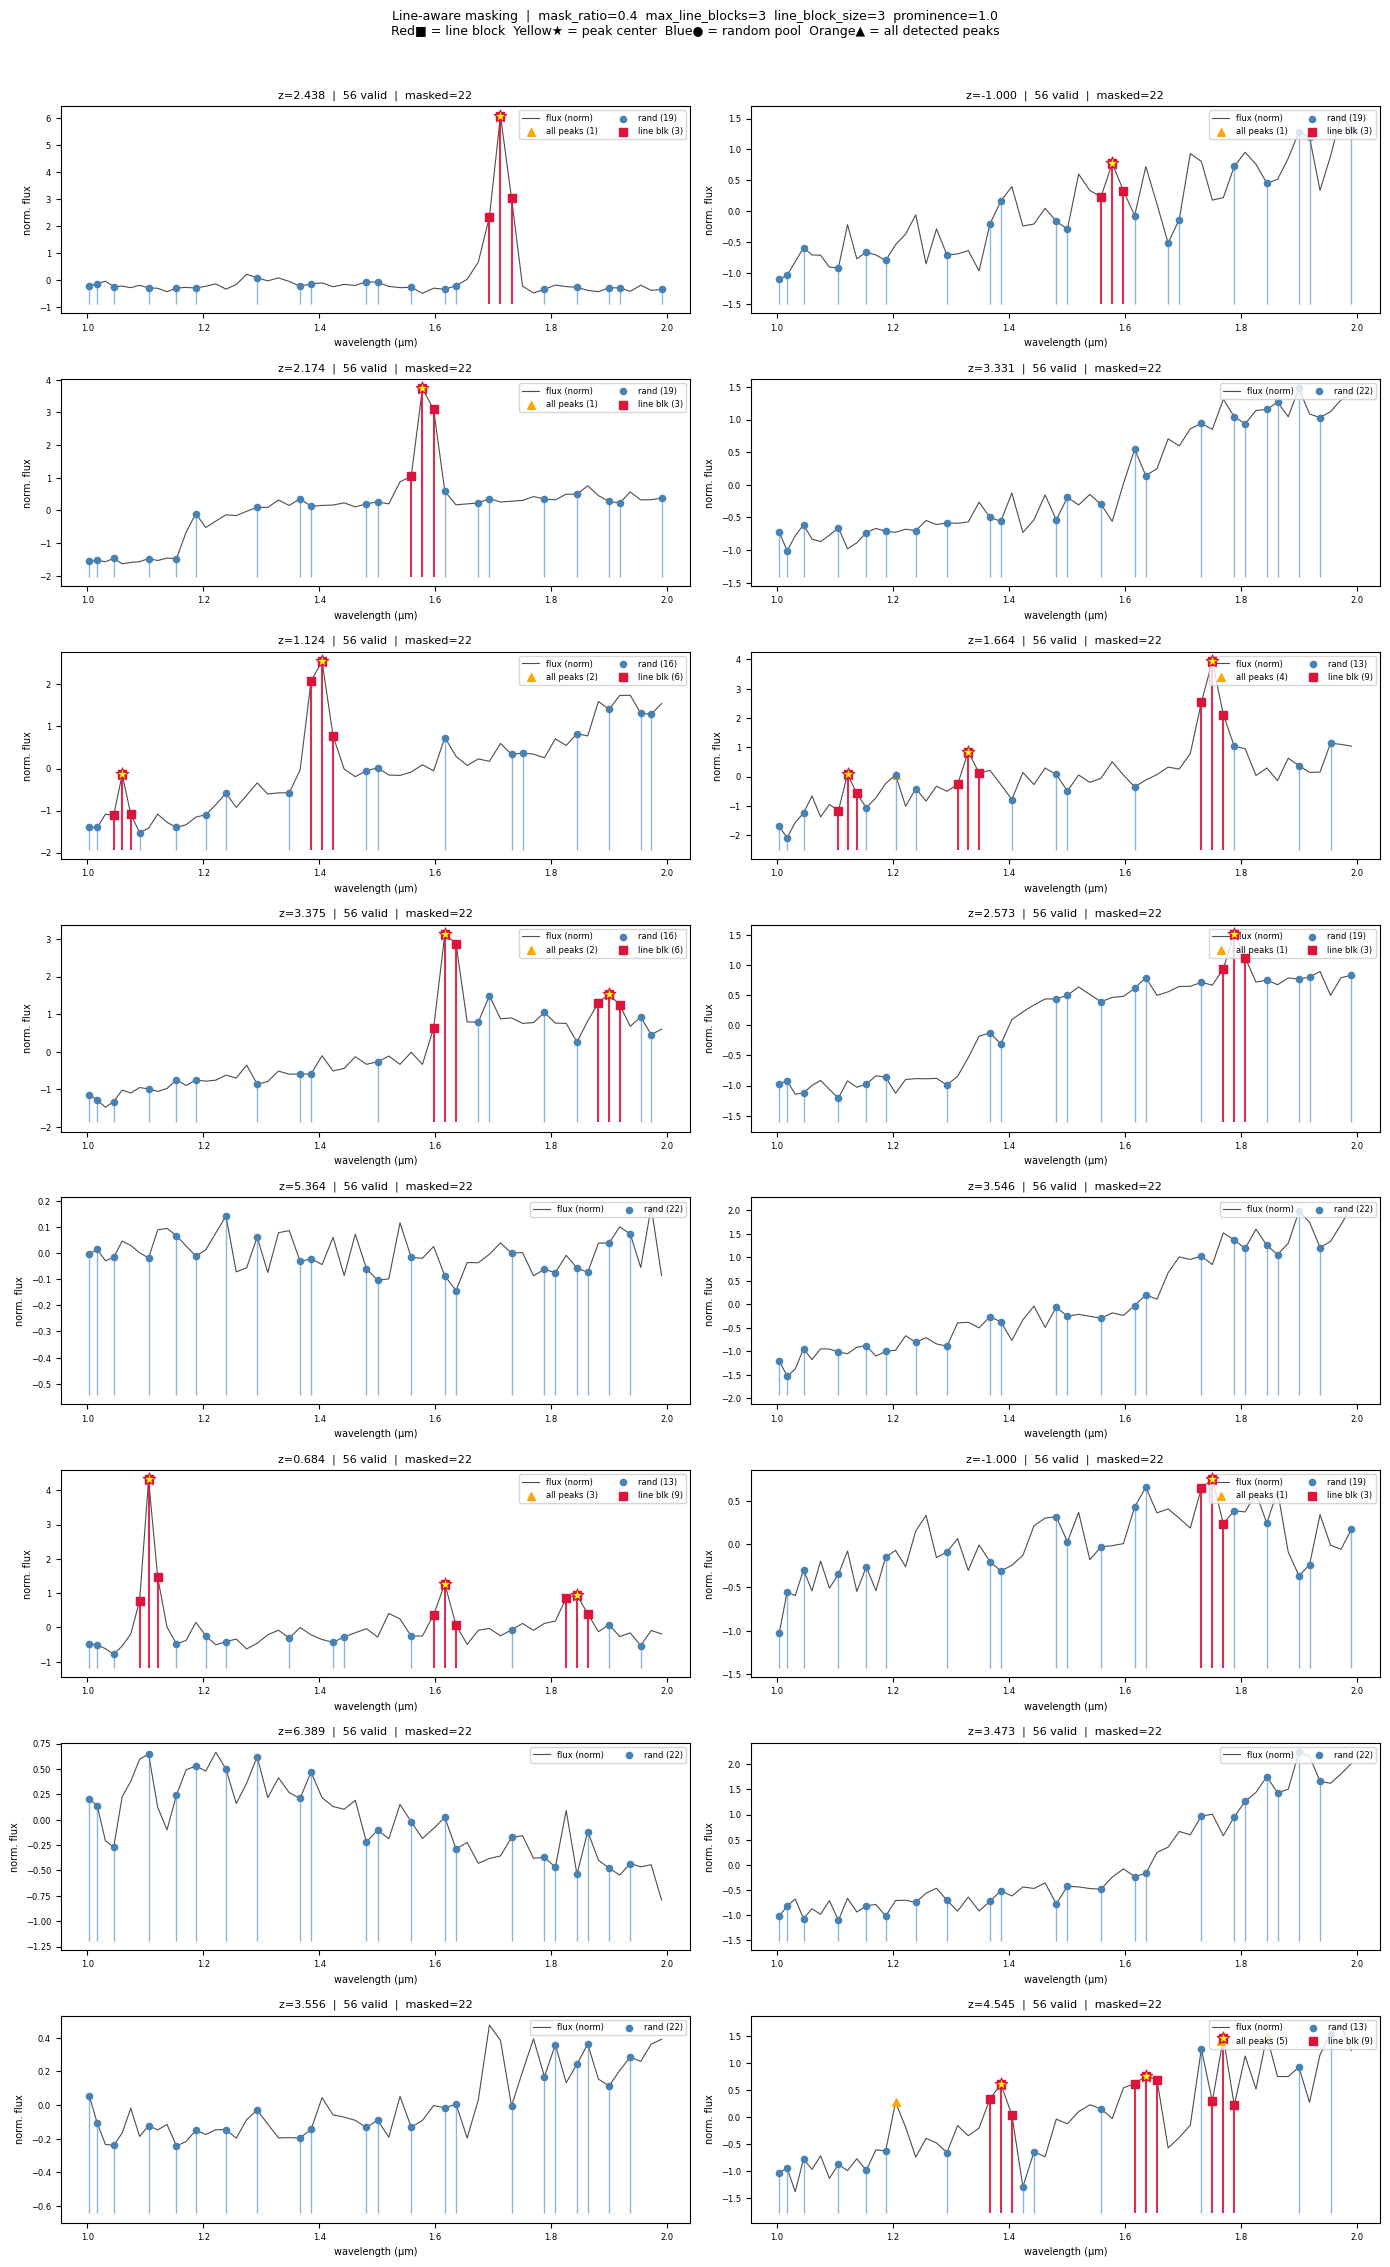

In [33]:
# ── Plot: 16 example spectra ──────────────────────────────────────────────────
ncols = 2
nrows = (N_SHOW + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(14, nrows * 2.8))
axes = axes.flatten()

for ax, sp in zip(axes, spectra):
    flux = sp["flux"]; wave = sp["wave"]; z = sp["z"]
    valid = (flux != 0.0) & np.isfinite(flux)
    if valid.sum() < 5:
        ax.set_visible(False); continue

    flux_n, _, _ = normalize(flux, valid)
    mask, line_idx, rand_idx, peak_idx = line_aware_mask(
        flux_n, valid,
        mask_ratio=MASK_RATIO,
        max_line_blocks=MAX_LINE_BLOCKS,
        line_block_size=LINE_BLOCK_SIZE,
        prominence=PROMINENCE,
        seed=0,
    )
    ymin = flux_n[valid].min() - 0.4

    ax.plot(wave, flux_n, color="0.3", lw=0.8, zorder=1, label="flux (norm)")

    if len(peak_idx) > 0:
        ax.scatter(wave[peak_idx], flux_n[peak_idx],
                   marker="^", s=30, color="orange", zorder=2,
                   label=f"all peaks ({len(peak_idx)})")
    if len(rand_idx) > 0:
        ax.vlines(wave[rand_idx], ymin, flux_n[rand_idx],
                  color="steelblue", lw=1.0, alpha=0.6, zorder=3)
        ax.scatter(wave[rand_idx], flux_n[rand_idx],
                   marker="o", s=20, color="steelblue", zorder=4,
                   label=f"rand ({len(rand_idx)})")
    if len(line_idx) > 0:
        ax.vlines(wave[line_idx], ymin, flux_n[line_idx],
                  color="crimson", lw=1.5, alpha=0.9, zorder=5)
        ax.scatter(wave[line_idx], flux_n[line_idx],
                   marker="s", s=35, color="crimson", zorder=6,
                   label=f"line blk ({len(line_idx)})")
        peak_in = np.intersect1d(line_idx, peak_idx)
        if len(peak_in) > 0:
            ax.scatter(wave[peak_in], flux_n[peak_in],
                       marker="*", s=90, color="yellow",
                       edgecolors="crimson", linewidths=0.8, zorder=7)

    title = (f"z={z:.3f}" if np.isfinite(z) else "z=?")
    title += f"  |  {valid.sum()} valid  |  masked={mask.sum()}"
    ax.set_title(title, fontsize=8)
    ax.set_xlabel("wavelength (µm)", fontsize=7)
    ax.set_ylabel("norm. flux", fontsize=7)
    ax.tick_params(labelsize=6)
    ax.legend(fontsize=6, loc="upper right", ncol=2)

for ax in axes[len(spectra):]:
    ax.set_visible(False)

plt.suptitle(
    f"Line-aware masking  |  mask_ratio={MASK_RATIO}  "
    f"max_line_blocks={MAX_LINE_BLOCKS}  line_block_size={LINE_BLOCK_SIZE}  prominence={PROMINENCE}\n"
    "Red■ = line block  Yellow★ = peak center  Blue● = random pool  Orange▲ = all detected peaks",
    fontsize=9, y=1.01,
)
plt.tight_layout()
plt.savefig("line_masking_examples.png", dpi=120, bbox_inches="tight")
plt.show()

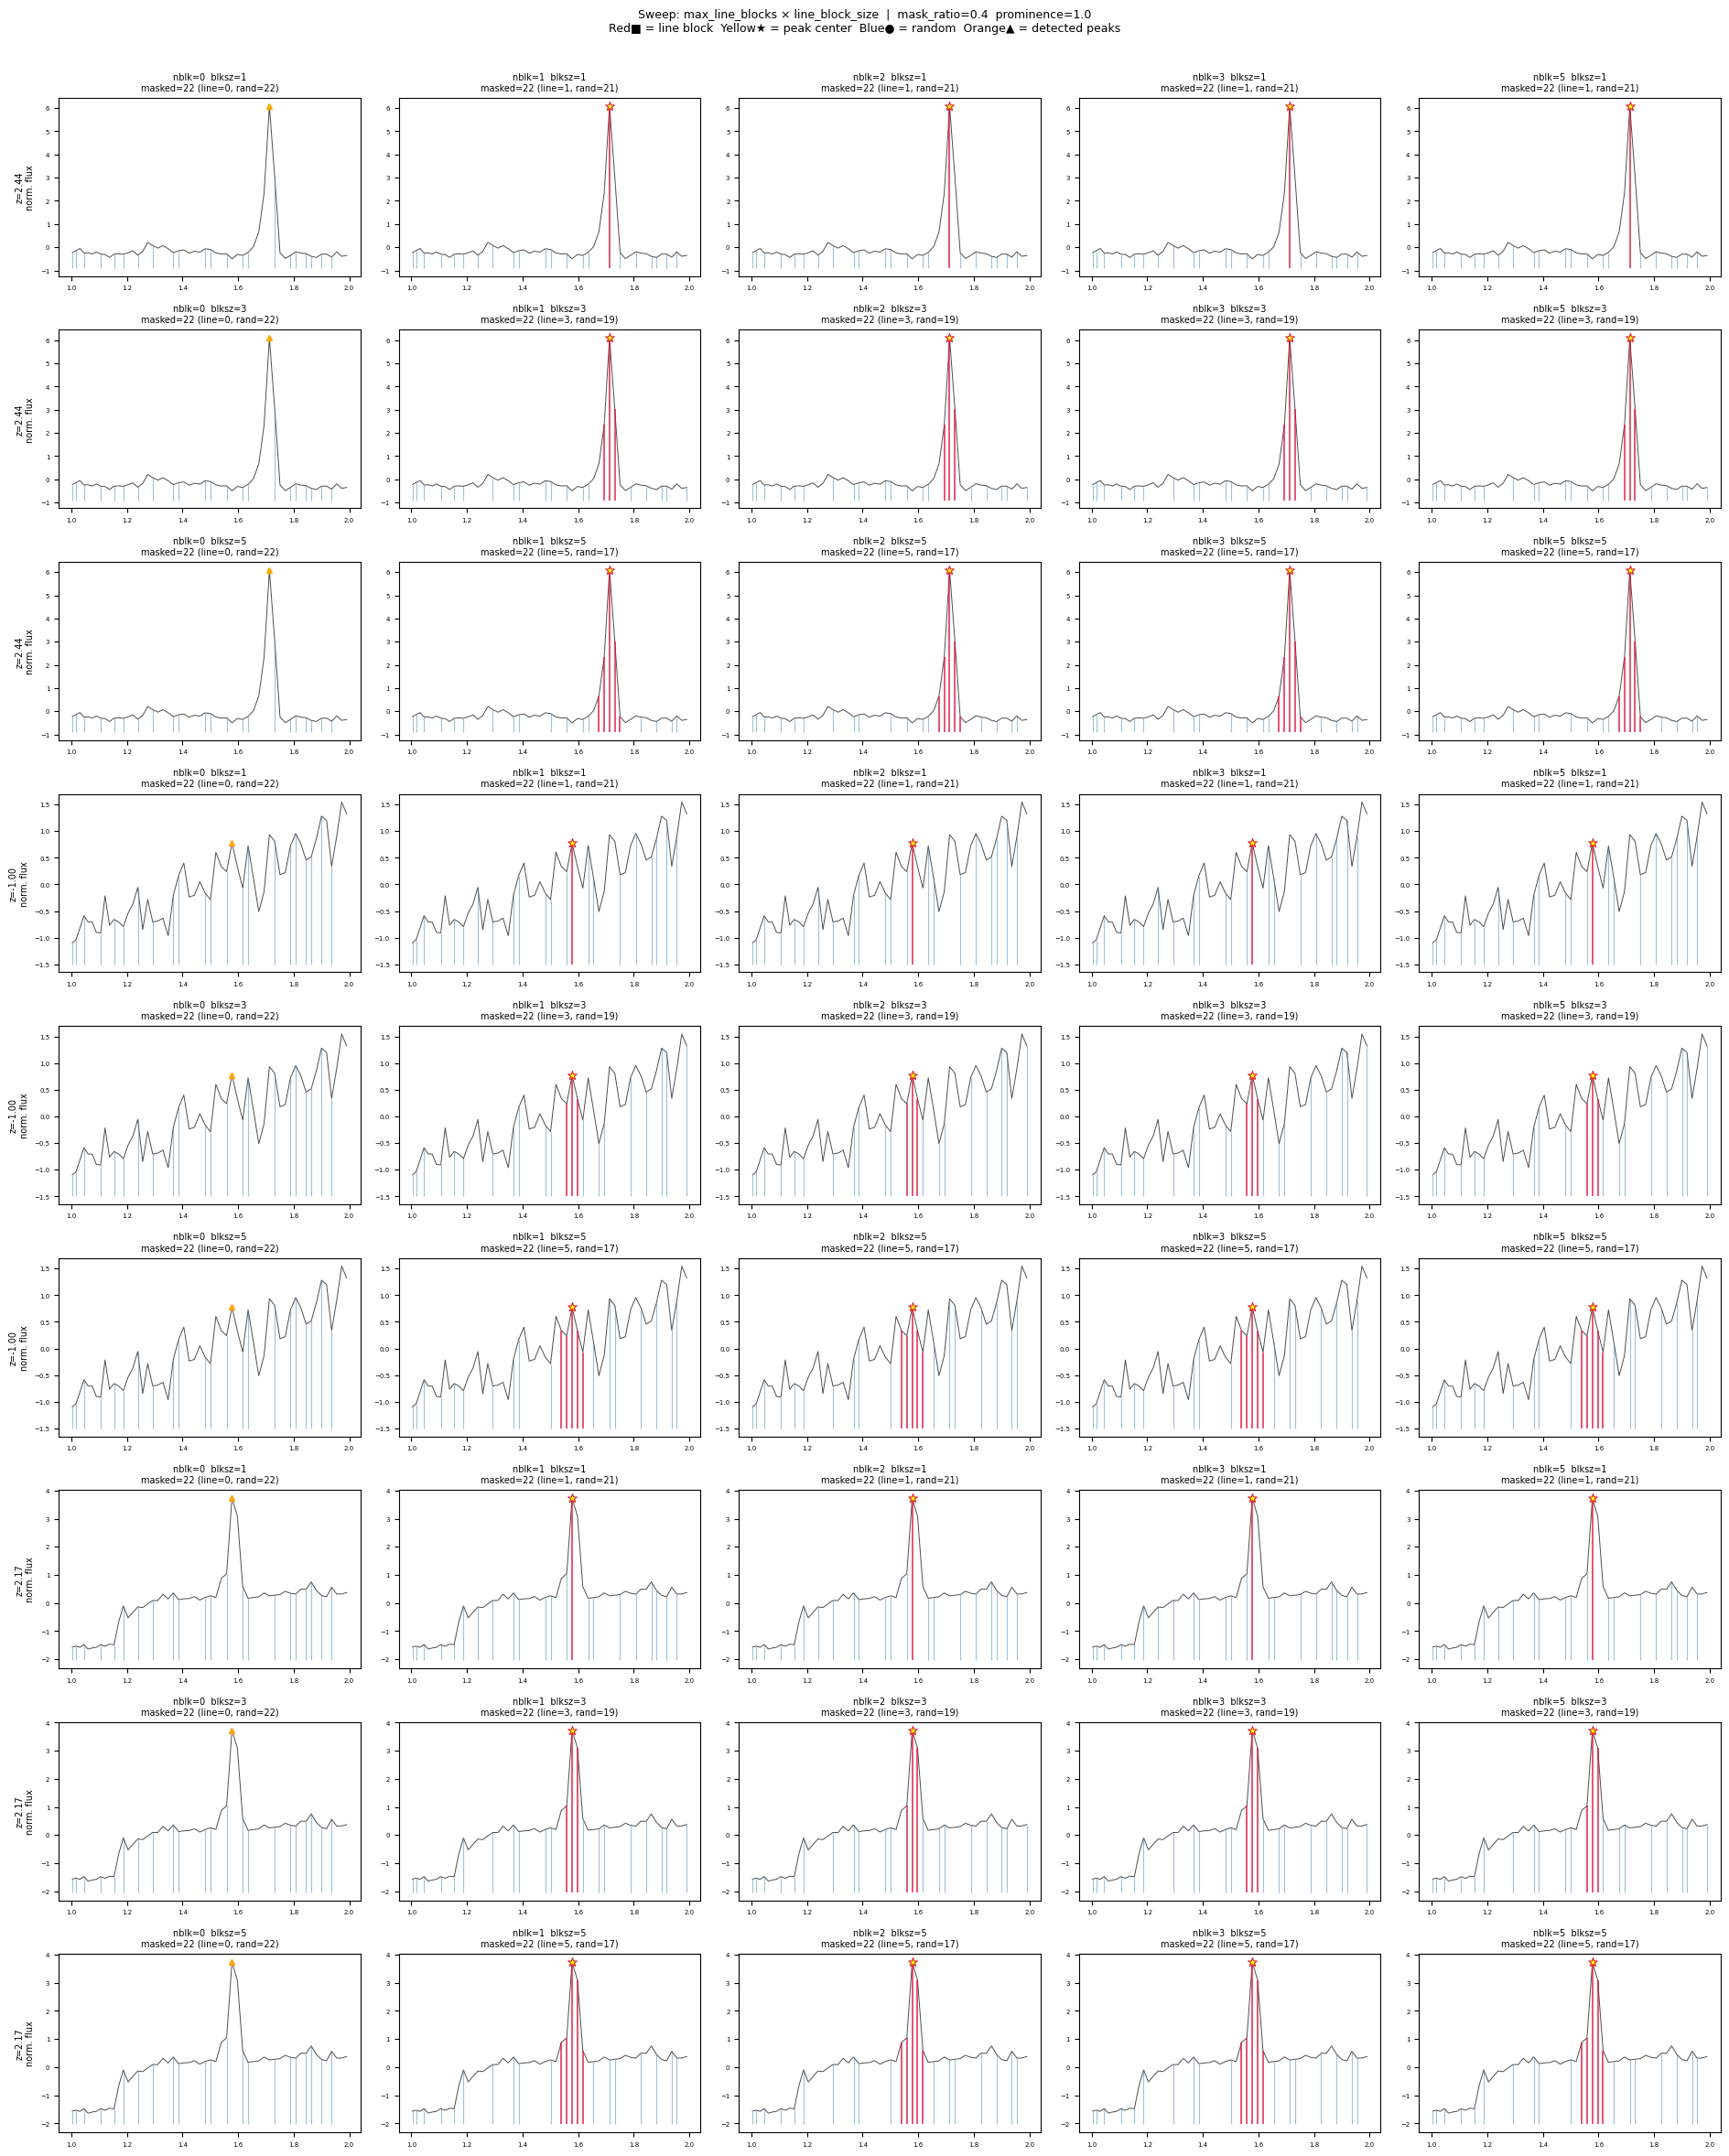

In [34]:
# ── Sweep: max_line_blocks × line_block_size on 3 spectra ────────────────────
NBLK_VALUES  = [0, 1, 2, 3, 5]   # 0 = pure random baseline
BSIZE_VALUES = [1, 3, 5]
EXAMPLES     = spectra[:3]

fig, axes = plt.subplots(
    len(EXAMPLES) * len(BSIZE_VALUES), len(NBLK_VALUES),
    figsize=(3.8 * len(NBLK_VALUES), 2.6 * len(EXAMPLES) * len(BSIZE_VALUES)),
)
axes = axes.reshape(len(EXAMPLES) * len(BSIZE_VALUES), len(NBLK_VALUES))

for ei, sp in enumerate(EXAMPLES):
    flux = sp["flux"]; wave = sp["wave"]; z = sp["z"]
    valid = (flux != 0.0) & np.isfinite(flux)
    flux_n, _, _ = normalize(flux, valid)
    ymin = flux_n[valid].min() - 0.4

    for bi, bsize in enumerate(BSIZE_VALUES):
        row = ei * len(BSIZE_VALUES) + bi
        for col, nblk in enumerate(NBLK_VALUES):
            ax = axes[row, col]
            mask, li, ri, pi = line_aware_mask(
                flux_n, valid,
                mask_ratio=MASK_RATIO,
                max_line_blocks=nblk,
                line_block_size=bsize,
                prominence=PROMINENCE,
                seed=0,
            )
            ax.plot(wave, flux_n, color="0.3", lw=0.7, zorder=1)
            if len(pi) > 0:
                ax.scatter(wave[pi], flux_n[pi], marker="^", s=18,
                           color="orange", zorder=2)
            if len(ri) > 0:
                ax.vlines(wave[ri], ymin, flux_n[ri],
                          color="steelblue", lw=0.8, alpha=0.5, zorder=3)
            if len(li) > 0:
                ax.vlines(wave[li], ymin, flux_n[li],
                          color="crimson", lw=1.2, alpha=0.85, zorder=4)
                peak_in = np.intersect1d(li, pi)
                if len(peak_in) > 0:
                    ax.scatter(wave[peak_in], flux_n[peak_in], marker="*",
                               s=55, color="yellow", edgecolors="crimson",
                               linewidths=0.7, zorder=5)

            t = f"nblk={nblk}  blksz={bsize}\nmasked={mask.sum()} (line={len(li)}, rand={len(ri)})"
            if col == 0:
                zlabel = f"z={z:.2f}" if np.isfinite(z) else "z=?"
                ax.set_ylabel(f"{zlabel}\nnorm. flux", fontsize=7)
            ax.set_title(t, fontsize=7)
            ax.tick_params(labelsize=5)

plt.suptitle(
    f"Sweep: max_line_blocks × line_block_size  |  mask_ratio={MASK_RATIO}  prominence={PROMINENCE}\n"
    "Red■ = line block  Yellow★ = peak center  Blue● = random  Orange▲ = detected peaks",
    fontsize=9, y=1.005,
)
plt.tight_layout()
plt.savefig("line_masking_sweep.png", dpi=110, bbox_inches="tight")
plt.show()